# Image Processing Notebook: Plot the H Cross-Section (from Transmission)


This notebook takes the processed transmission imagesand plot the H Cross-sections from specific ROIs

## Initial Settings

### Import Libraries

In [1]:
import sys
sys.path.append(r'..\01_Functions')
from step_functions import *
from dict_functions import *
from proc_functions import *
from img_functions import *
from plotting_cs import *
import seaborn as sns
%matplotlib inline
pd.set_option('display.max_rows', None)

### Provide Directories

#### Provide the directory for transmission images

In [2]:
# %load select_directory('src_dir')
src_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\01_Transmission_results\exp2000_trans\01_LP30_deg"

#### Provide the Spectra.txt file from any of the experiments. 
These are the neutron arrival times the MCP detected

In [3]:
# %load select_file('spectra_file')
spectra_file = r"J:\700 Campaigns - internal\2022\PSI22_04NI\Raw_images\exp2000\exp2200_LP40_deg\02_pos00\IMAT00018918_02_pos00_001_Spectra.txt"

### Read the directory and extract values from images
You can specify a single folder but if you want all the folders in the `src_dir`, leave `proc_folder=[]`.

In [4]:
stack_dict = read_saved_dict (src_dir, proc_folder = [])

Reading Images: 100%|████████████████████████████| 5/5 [00:04<00:00,  1.13it/s]


#### Extract an averaged image for each key
For each `proc_folder` (acquisition), an averaged image will be extracted

In [5]:
avg_imgs = []
for key, value in stack_dict.items():
    img =  avg_frames_dict (value, output_type = 'img', start_slice = 30, end_slice = 50)
    avg_imgs.append(img[0])

#### Select the ROIs
For simplicity handling the names, `ROIs_` before the name of the `proc_folder` is required

In [6]:
# %load select_multiple_rois(proc_folder[0], avg_images[0], cmap = 'flag')

# degrad LP30
ROIs_02_pos00 = [[292, 65, 160, 149], [64, 66, 160, 149], [64, 300, 160, 149], [294, 299, 160, 149]]
ROIs_04_pos01 = [[292, 66, 160, 149], [64, 66, 160, 149], [64, 300, 160, 90], [294, 299, 160, 90]] #
#ROIs_06_pos02 = [[292, 65, 160, 149], [64, 66, 160, 149], [64, 300, 160, 149], [294, 299, 160, 149]]
ROIs_06_pos02 = [[292, 65, 160, 149], [64, 66, 160, 149], [294, 299, 160, 149]]
ROIs_08_pos03 = [[335, 59, 99, 94], [78, 94, 132, 126], [64, 300, 160, 149], [294, 299, 160, 149]]
#ROIs_10_pos04 = [[292, 65, 160, 149], [64, 66, 160, 149], [64, 300, 160, 149], [294, 299, 160, 149]]
ROIs_10_pos04 = [[64, 66, 160, 149], [64, 300, 160, 149], [294, 299, 160, 149]]

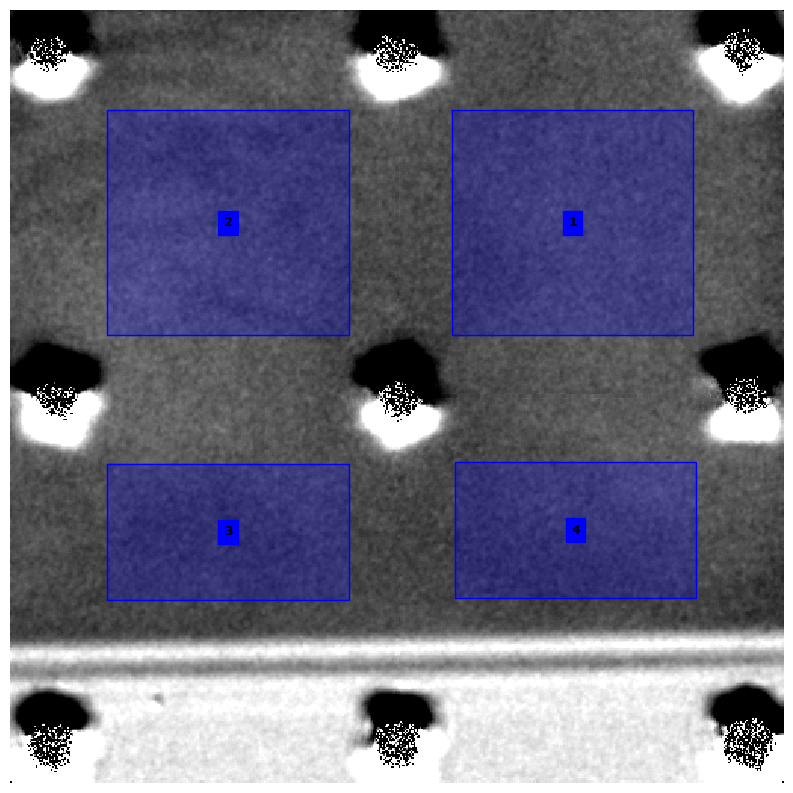

In [7]:
show_img(avg_imgs[1], dr = [(ROIs_04_pos01, 'blue')], cmap='gray')

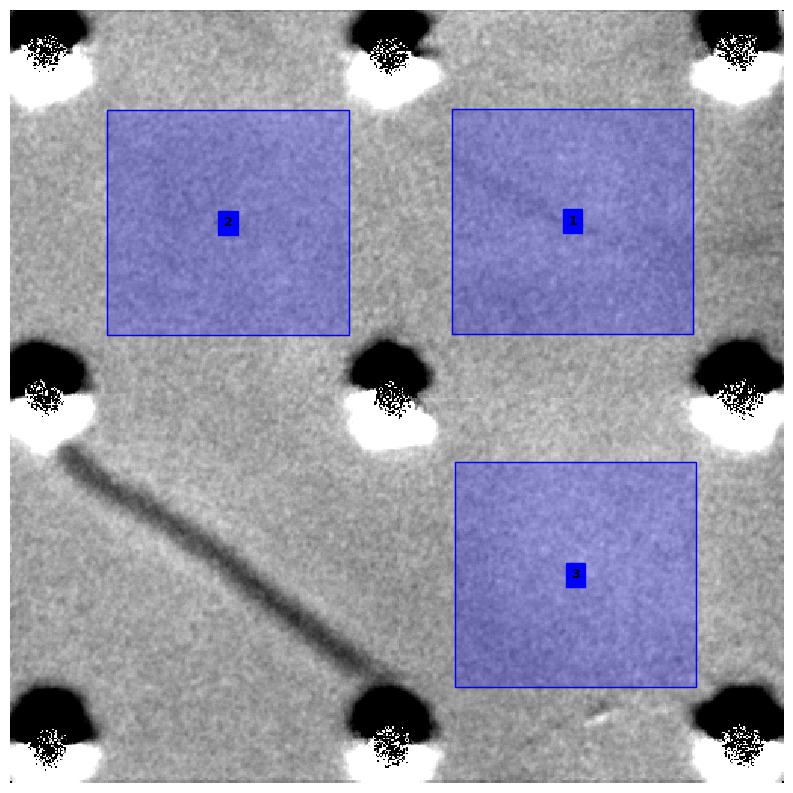

In [8]:
show_img(avg_imgs[2], dr = [(ROIs_06_pos02, 'blue')], cmap='gray')

#### Create a dictionary of the ROIs

In [9]:
rois_dict = {}
for name in stack_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        rois_dict[rois] = eval(rois)

### Extract the intesity/transmission values

In [10]:
table_val_rois = get_roi_values (stack_dict, rois_dict, spectra_file, binning = 10, flight_path = 56.5, start_slice = 0)

In [11]:
table_val_rois = table_val_rois.loc[3:71]
table_val_rois = table_val_rois.reset_index(drop=True)
data_wvl = table_val_rois['Wavelength [Å]']
#table_val_rois
#table_val_rois = dataframe_to_savgol(table_val_rois, 15, 2)

### Get the transmission table
If the images given before are transmission, leave empty the data_ref in the `prepare_trans_data` function. 
If not, run the previous line but with the reference images directory.

Depending on the **data_output** chosen ('transmission'. 'optical density', 'total cs', or 'h cs'). if the requested data is `total cs` or `h cs`, a dictionary of compounds is required. This is basically a list of the material expected **in oder** from the ROIs given before.

The  full dictionary of cross-sections is located at the top of the `plotting_cs` function. In the notebook, we are using only those that are required to avoid clogging the information.

In [12]:
thickness = 0.056
ec = {'abbv': 'EC', 'composition' : {'C':3.0, 'H':4.0, 'O':3.0},'density':1.32, 'thickness': thickness}
dmc = {'abbv': 'DMC','composition' : {'C':3.0, 'H':6.0, 'O':3.0}, 'density':1.07, 'thickness': thickness}
lipf6 = {'abbv': 'LiPF6','composition' : {'LI':1.0, 'P':1.0, 'F':6.0}, 'density':1.5, 'thickness': thickness}
lp30 = {'abbv': 'LP30','molecules' : [ec, 0.406359477,dmc, 0.501683056, lipf6, 0.091957467], 'density':1.2795, 'thickness': thickness}

In [13]:
compounds_dict = [lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30,
                 lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30]

In [14]:
res_data = prepare_trans_data(table_val_rois, data_output = 'h cs', compounds_dict = compounds_dict)

Data_imgs variable taken as transmission images


In [15]:
#res_data = dataframe_to_savgol(res_data, 15, 2)

In [16]:
    # position column name extraction
pos00 = [column for column in res_data if 'pos00' in column]
pos01 = [column for column in res_data if 'pos01' in column]
pos02 = [column for column in res_data if 'pos02' in column]
pos03 = [column for column in res_data if 'pos03' in column]
pos04 = [column for column in res_data if 'pos04' in column]
    # recalling the data with the specified columns and the wavelength column up front
cs_pos00_dat = pd.concat([data_wvl, res_data[pos00]], axis = 1)
cs_pos01_dat = pd.concat([data_wvl, res_data[pos01]], axis = 1)
cs_pos02_dat = pd.concat([data_wvl, res_data[pos02]], axis = 1)
cs_pos03_dat = pd.concat([data_wvl, res_data[pos03]], axis = 1)
cs_pos04_dat = pd.concat([data_wvl, res_data[pos04]], axis = 1)

avg_vals = pd.DataFrame(data_wvl)
avg_vals ['pos00'] = cs_pos00_dat.iloc[:,1:].mean(axis=1)
avg_vals ['pos01'] = cs_pos01_dat.iloc[:,1:].mean(axis=1)
avg_vals ['pos02'] = cs_pos02_dat.iloc[:,1:].mean(axis=1)
avg_vals ['pos03'] = cs_pos03_dat.iloc[:,1:].mean(axis=1)
avg_vals ['pos04'] = cs_pos04_dat.iloc[:,1:].mean(axis=1)

In [17]:
cs_pos00_dat=cs_pos00_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos01_dat=cs_pos01_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos02_dat=cs_pos02_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos03_dat=cs_pos03_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos04_dat=cs_pos04_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
avg_vals=avg_vals.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')

In [18]:
#sns.relplot(data = cs_pos01_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val', 
#            kind = 'line', legend = 'brief', height=6, aspect=1.2)

<AxesSubplot:xlabel='Wavelength [Å]', ylabel='cross-section [barns]'>

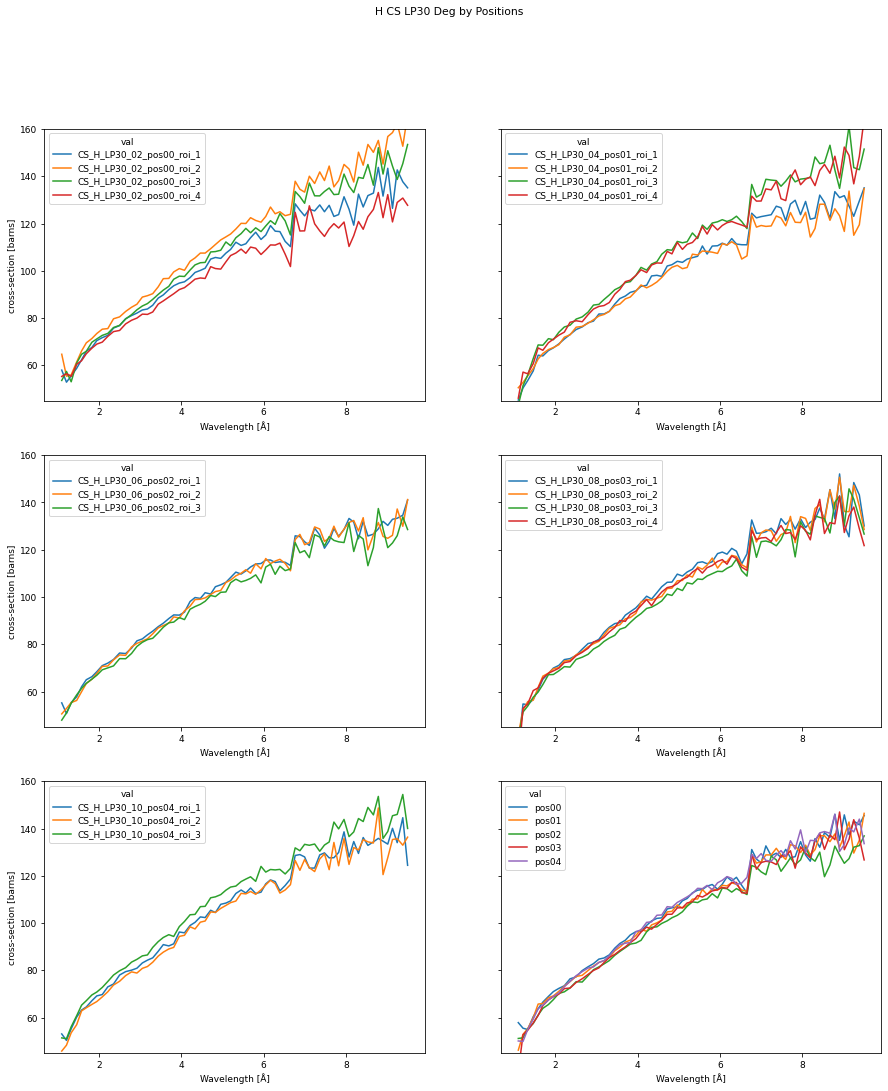

In [19]:
fig0, ax = plt.subplots(3,2, figsize = (15,17), sharey = True)
fig0.suptitle('H CS LP30 Deg by Positions')
plt.ylim([45,160])
sns.lineplot(ax = ax[0,0], data = cs_pos00_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[0,1], data = cs_pos01_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[1,0], data = cs_pos02_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[1,1], data = cs_pos03_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[2,0], data = cs_pos04_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[2,1], data = avg_vals, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')

### Normalization by PE and 3A

In [20]:
res_data_PEnorm = normalize_to_PE(res_data)

In [21]:
res_data_PEn3Anorm = normalize_to_range(res_data_PEnorm, idx_range = [3,3])

In [22]:
#res_data_PEn3Anorm = dataframe_to_savgol(res_data_PEn3Anorm, 9, 2)

In [23]:
    # position column name extraction
pos00 = [column for column in res_data_PEn3Anorm if 'pos00' in column]
pos01 = [column for column in res_data_PEn3Anorm if 'pos01' in column]
pos02 = [column for column in res_data_PEn3Anorm if 'pos02' in column]
pos03 = [column for column in res_data_PEn3Anorm if 'pos03' in column]
pos04 = [column for column in res_data_PEn3Anorm if 'pos04' in column]
    # recalling the data with the specified columns and the wavelength column up front
cs_pos00_norm = pd.concat([data_wvl, res_data_PEn3Anorm[pos00]], axis = 1)
cs_pos01_norm = pd.concat([data_wvl, res_data_PEn3Anorm[pos01]], axis = 1)
cs_pos02_norm = pd.concat([data_wvl, res_data_PEn3Anorm[pos02]], axis = 1)
cs_pos03_norm = pd.concat([data_wvl, res_data_PEn3Anorm[pos03]], axis = 1)
cs_pos04_norm = pd.concat([data_wvl, res_data_PEn3Anorm[pos04]], axis = 1)

avg_vals = pd.DataFrame(data_wvl)
avg_vals ['pos00'] = cs_pos00_norm.iloc[:,1:].mean(axis=1)
avg_vals ['pos01'] = cs_pos01_norm.iloc[:,1:].mean(axis=1)
avg_vals ['pos02'] = cs_pos02_norm.iloc[:,1:].mean(axis=1)
avg_vals ['pos03'] = cs_pos03_norm.iloc[:,1:].mean(axis=1)
avg_vals ['pos04'] = cs_pos04_norm.iloc[:,1:].mean(axis=1)

In [24]:
#avg_vals = dataframe_to_savgol(avg_vals, 7, 2)

In [25]:
cs_pos00_norm=cs_pos00_norm.melt('Wavelength [Å]', var_name='val', value_name='Normalized cross-section [-]')
cs_pos01_norm=cs_pos01_norm.melt('Wavelength [Å]', var_name='val', value_name='Normalized cross-section [-]')
cs_pos02_norm=cs_pos02_norm.melt('Wavelength [Å]', var_name='val', value_name='Normalized cross-section [-]')
cs_pos03_norm=cs_pos03_norm.melt('Wavelength [Å]', var_name='val', value_name='Normalized cross-section [-]')
cs_pos04_norm=cs_pos04_norm.melt('Wavelength [Å]', var_name='val', value_name='Normalized cross-section [-]')
avg_vals=avg_vals.melt('Wavelength [Å]', var_name='val', value_name='Normalized cross-section [-]')

<AxesSubplot:xlabel='Wavelength [Å]', ylabel='Normalized cross-section [-]'>

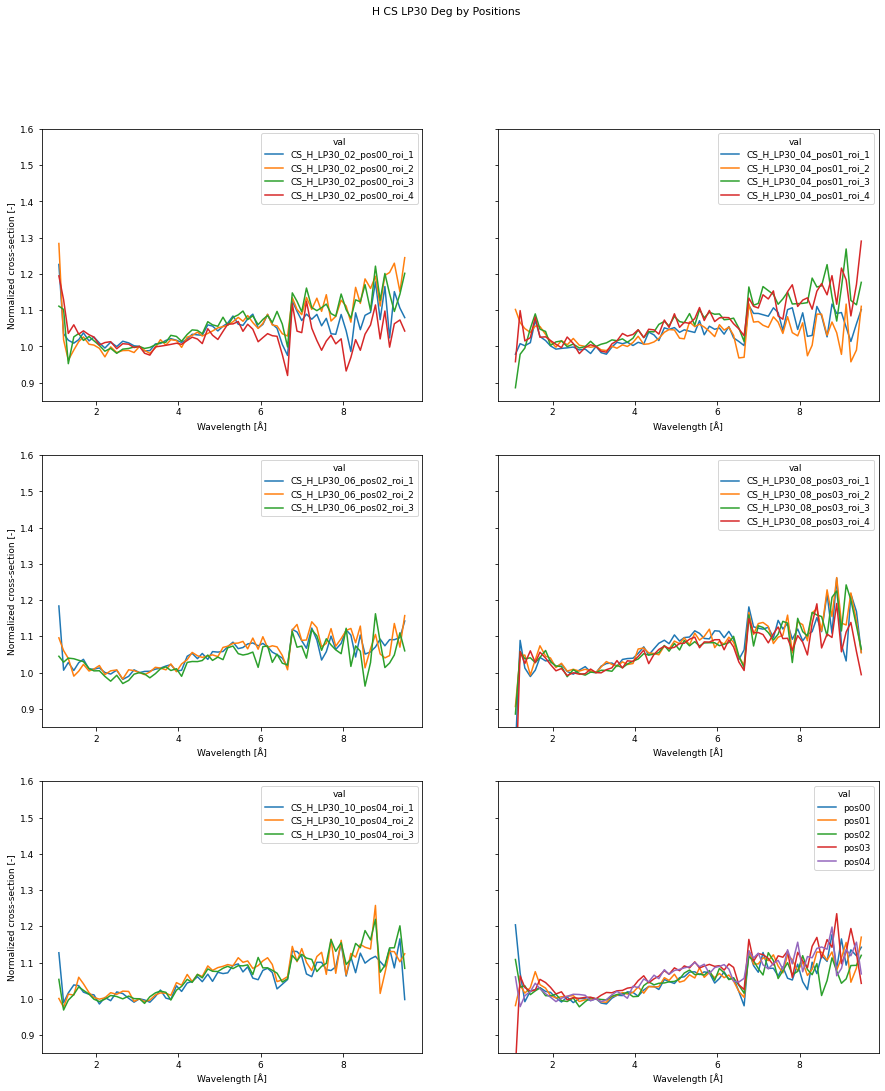

In [26]:
fig1, ax = plt.subplots(3,2, figsize = (15,17), sharey = True)
fig1.suptitle('H CS LP30 Deg by Positions')
#ax[0,0].set_title('Pos00')
plt.ylim([0.85,1.6])
sns.lineplot(ax = ax[0,0], data = cs_pos00_norm, x = 'Wavelength [Å]', y = 'Normalized cross-section [-]', hue = 'val')
sns.lineplot(ax = ax[0,1], data = cs_pos01_norm, x = 'Wavelength [Å]', y = 'Normalized cross-section [-]', hue = 'val')
sns.lineplot(ax = ax[1,0], data = cs_pos02_norm, x = 'Wavelength [Å]', y = 'Normalized cross-section [-]', hue = 'val')
sns.lineplot(ax = ax[1,1], data = cs_pos03_norm, x = 'Wavelength [Å]', y = 'Normalized cross-section [-]', hue = 'val')
sns.lineplot(ax = ax[2,0], data = cs_pos04_norm, x = 'Wavelength [Å]', y = 'Normalized cross-section [-]', hue = 'val')
sns.lineplot(ax = ax[2,1], data = avg_vals, x = 'Wavelength [Å]', y = 'Normalized cross-section [-]', hue = 'val')

In [27]:
    # extraction of rois from all positions (chip analysis)
roi1 = [column for column in res_data if 'roi1' in column]
roi2 = [column for column in res_data if 'roi2' in column]
roi3 = [column for column in res_data if 'roi3' in column]
roi4 = [column for column in res_data if 'roi4' in column]
    # recalling the data with the specified columns and the wavelength column up front
cs_roi1_dat = pd.concat([data_wvl, res_data[roi1]], axis = 1)
cs_roi2_dat = pd.concat([data_wvl, res_data[roi2]], axis = 1)
cs_roi3_dat = pd.concat([data_wvl, res_data[roi3]], axis = 1)
cs_roi4_dat = pd.concat([data_wvl, res_data[roi4]], axis = 1)